# 14 — Portfolio VaR Dashboard: The Complete Picture

**Lesson:** Portfolio VaR tells you *how much* you might lose. The diversification benefit tells you *how reliable* that number is. Correlation tells you *why* it's changing. And the correlation-adjusted VaR — refined through the asymmetric blend experiment (Notebook 15b) — tells you *what number to use* when correlation is shifting. Together, they form a complete risk monitoring system.

This notebook is the culmination of everything we've built — the single-asset dashboard methods (Notebook 11) extended to a 60/40 SPY/BND portfolio, plus the portfolio-specific signals (Notebooks 12, 13, 15, 15b): diversification benefit, correlation ratio, and the refined asymmetric correlation-adjusted VaR.

**Scenario:** You manage a £10M 60/40 SPY/BND portfolio. Your daily risk check answers four questions:

1. **How much?** — What's the VaR across all methods?
2. **How reliable?** — Is diversification working, or are assets moving together?
3. **Why?** — Is correlation shifting, and in which direction?
4. **What to use?** — Is standard VaR stale? The asymmetric adjusted VaR (Notebook 15b) gives you a better-calibrated number.

## ⚙️ Parameters

Change these and re-run all cells to see the effect.

In [1]:
# ⚙️ Parameters
TICKERS = ["SPY", "BND"]
WEIGHTS = [0.60, 0.40]
START_DATE = "2018-01-01"
END_DATE = None
CONFIDENCE = 0.95
VAR_WINDOW = 252
VOL_WINDOW = 20
LAMBDA = 0.94

# Correlation monitoring
CORR_WINDOW_SLOW = 252
CORR_WINDOW_FAST = 60

# Asymmetric correlation-adjusted VaR parameters (optimal from Notebook 15b)
ASYM_THRESHOLD = 1.2   # Only activate when correlation is rising above this
ASYM_BLEND_MAX = 3.0   # Full blend toward naive sum at this ratio

# Position
PORTFOLIO_VALUE = 10_000_000  # £10M 60/40 portfolio

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.historical_var import historical_var
from src.decay import decay_var
from src.rolling import rolling_var, rolling_decay_var, breach_summary
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
# Download and prepare data
prices = {}
returns = {}

for ticker in TICKERS:
    prices[ticker] = download_close_prices(ticker, start=START_DATE, end=END_DATE)
    returns[ticker] = prepare_returns(prices[ticker])
    print(f"{ticker}: {len(returns[ticker])} daily returns, "
          f"{returns[ticker].index[0].date()} to {returns[ticker].index[-1].date()}")

# Align dates (inner join — only days where both traded)
aligned = pd.DataFrame({
    TICKERS[0]: returns[TICKERS[0]],
    TICKERS[1]: returns[TICKERS[1]],
}).dropna()

n_dropped = len(returns[TICKERS[0]]) - len(aligned)
print(f"\nAligned returns: {len(aligned)} days ({n_dropped} dropped due to mismatched dates)")
print(f"Date range: {aligned.index[0].date()} to {aligned.index[-1].date()}")

# Portfolio returns
portfolio_returns = (WEIGHTS[0] * aligned[TICKERS[0]] +
                     WEIGHTS[1] * aligned[TICKERS[1]])

print(f"\nPortfolio returns: {len(portfolio_returns)} days")

Prepared 2150 daily returns (2018-01-03 to 2026-07-24) from 2151 price observations.
SPY: 2150 daily returns, 2018-01-03 to 2026-07-24


Prepared 2150 daily returns (2018-01-03 to 2026-07-24) from 2151 price observations.
BND: 2150 daily returns, 2018-01-03 to 2026-07-24

Aligned returns: 2150 days (0 dropped due to mismatched dates)
Date range: 2018-01-03 to 2026-07-24

Portfolio returns: 2150 days


---

## Part A: The portfolio VaR dashboard

Every VaR method we built for single assets works on portfolio returns — no changes needed. The portfolio return series already captures the real historical pairings between SPY and BND. Just compute it, then run the same functions.

The five methods form a monitoring system, each catching what the others miss.

In [4]:
# Equal-weighted and decay-weighted VaR on portfolio returns
equal = rolling_var(portfolio_returns, window=VAR_WINDOW, confidence=CONFIDENCE)
decay = rolling_decay_var(portfolio_returns, window=VAR_WINDOW, lam=LAMBDA, confidence=CONFIDENCE)
fast60 = rolling_var(portfolio_returns, window=60, confidence=CONFIDENCE)

print(f"Equal 252d:  {len(equal)} observations")
print(f"Decay 252d:  {len(decay)} observations")
print(f"Fast 60d:    {len(fast60)} observations")

Equal 252d:  1898 observations
Decay 252d:  1898 observations
Fast 60d:    2090 observations


In [5]:
# Vol-scaled and combined methods on portfolio returns
trailing_vol = portfolio_returns.rolling(window=VOL_WINDOW).std().clip(lower=0.001)

first_day = VAR_WINDOW + VOL_WINDOW
print(f"Computing vol-scaled and combined methods (starting day {first_day})...")

volscaled_var, volscaled_breach, volscaled_dates = [], [], []
combined_var, combined_breach, combined_dates = [], [], []

for day in range(first_day, len(portfolio_returns)):
    wr = portfolio_returns.iloc[day - VAR_WINDOW : day]
    wi = wr.index
    vc = trailing_vol.loc[wi[-1]]
    vh = trailing_vol.loc[wi].values
    if np.isnan(vh).any():
        continue
    sr = wr.values * (vc / vh)
    vs = historical_var(sr, confidence=CONFIDENCE)
    cb = decay_var(sr[::-1], lam=LAMBDA, confidence=CONFIDENCE)
    nr = portfolio_returns.iloc[day]
    volscaled_var.append(vs)
    volscaled_breach.append(-nr > vs)
    volscaled_dates.append(portfolio_returns.index[day])
    combined_var.append(cb)
    combined_breach.append(-nr > cb)
    combined_dates.append(portfolio_returns.index[day])

volscaled = pd.DataFrame(
    {"VaR": volscaled_var, "Breach": volscaled_breach},
    index=pd.DatetimeIndex(volscaled_dates, name="Date"))
combined = pd.DataFrame(
    {"VaR": combined_var, "Breach": combined_breach},
    index=pd.DatetimeIndex(combined_dates, name="Date"))

print(f"Vol-scaled: {len(volscaled)} observations")
print(f"Combined:   {len(combined)} observations")

Computing vol-scaled and combined methods (starting day 272)...


Vol-scaled: 1878 observations
Combined:   1878 observations


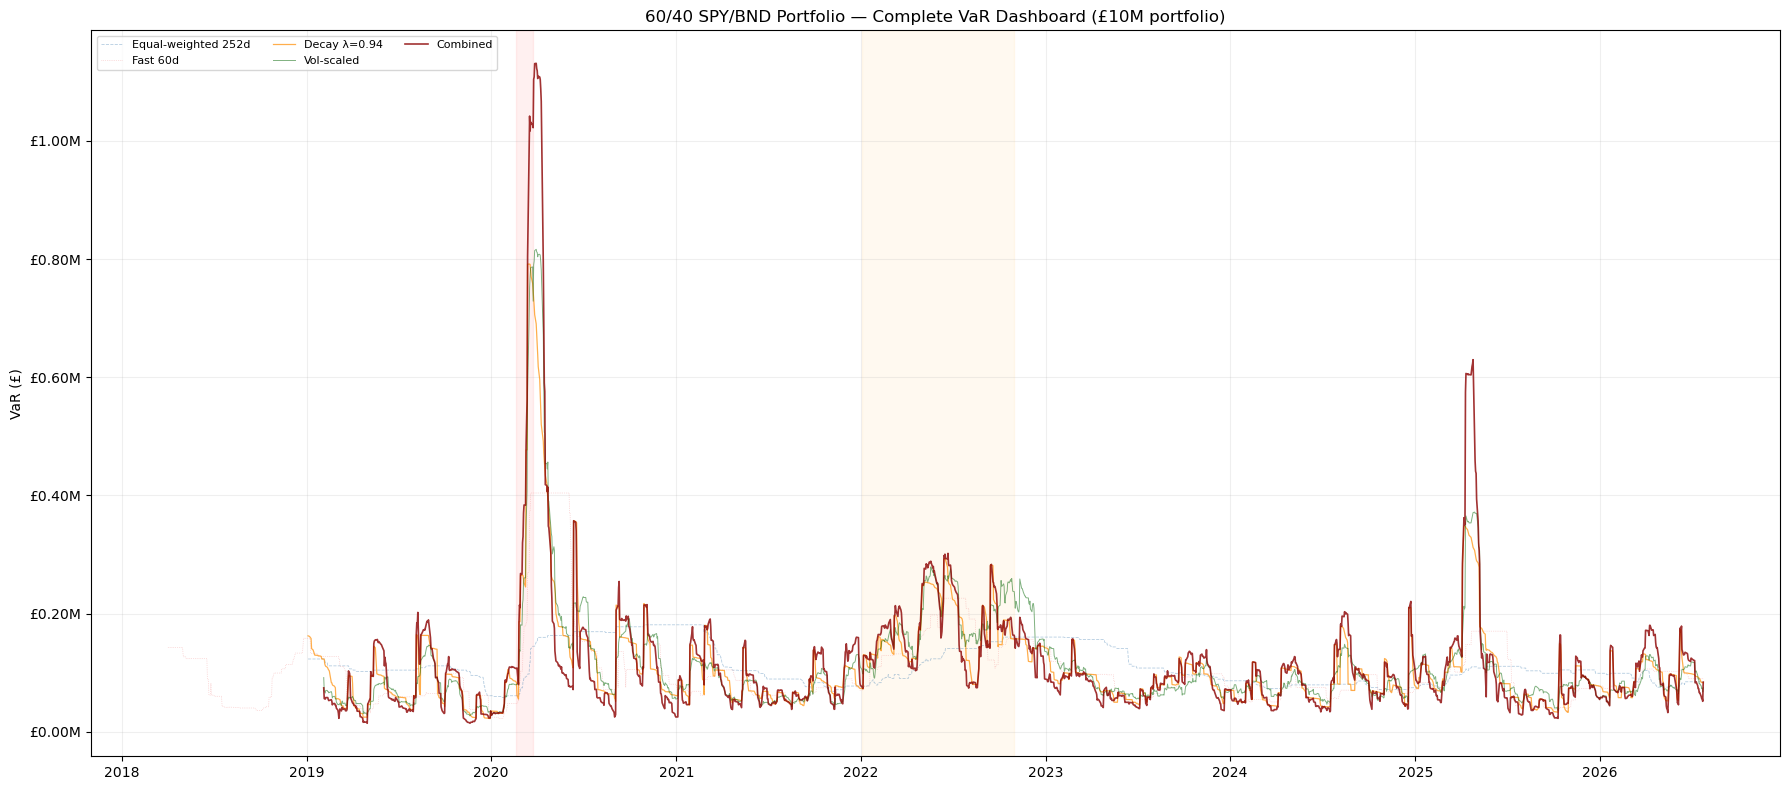

In [6]:
# The complete portfolio VaR dashboard
fig, ax = plt.subplots(figsize=(18, 8))

methods = [
    (equal, "Equal-weighted 252d", "steelblue", 0.4, "--", 0.6),
    (fast60, "Fast 60d", "lightcoral", 0.5, ":", 0.5),
    (decay, "Decay λ=0.94", "darkorange", 0.7, "-", 0.9),
    (volscaled, "Vol-scaled", "darkgreen", 0.5, "-", 0.7),
    (combined, "Combined", "darkred", 0.8, "-", 1.2),
]

for res, label, color, alpha, ls, lw in methods:
    ax.plot(res.index, res["VaR"] * PORTFOLIO_VALUE, linewidth=lw, color=color,
            alpha=alpha, linestyle=ls, label=label)

ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"), alpha=0.06, color="red")
ax.axvspan(pd.Timestamp("2022-01-03"), pd.Timestamp("2022-10-31"), alpha=0.06, color="orange")

ax.set_ylabel("VaR (£)")
ax.set_title(f"60/40 SPY/BND Portfolio — Complete VaR Dashboard (£{PORTFOLIO_VALUE/1e6:.0f}M portfolio)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1e6:.2f}M'))
ax.legend(loc="upper left", ncol=3, fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### What each method tells you — portfolio edition

| Method | Role in the dashboard | Failure mode |
|--------|----------------------|-------------|
| Equal 252d | Baseline — what does equal-weighted history say about this portfolio? | Slow to react to regime changes, including correlation shifts. |
| Fast 60d | Early warning — is something changing RIGHT NOW? | Noisy, prone to false alarms. |
| Decay λ=0.94 | Current risk — does recent data dominate? | Drops guard too fast during calm. |
| Vol-scaled | Regime context — is it just vol or is the return shape changing? | Shape-stability assumption. Scaling vol doesn't fix correlation shifts. |
| Combined | Best estimate — both ordering and magnitude fixed. | Three parameters, overfitting risk. |

**Portfolio-specific note:** The equal-weighted method uses real historical pairings — if SPY and BND didn't crash together in the window, the VaR reflects that diversification. But when correlation shifts (2022), the equal-weighted VaR is slow to catch up. The fast methods (60d, decay) pick up correlation shifts faster because they weight recent data more heavily.

---

## Part B: Method divergence as signal

The gaps between methods contain information. When all five agree, risk is unambiguous. When they disagree, something interesting is happening — and in a portfolio context, divergences often trace back to correlation shifts.

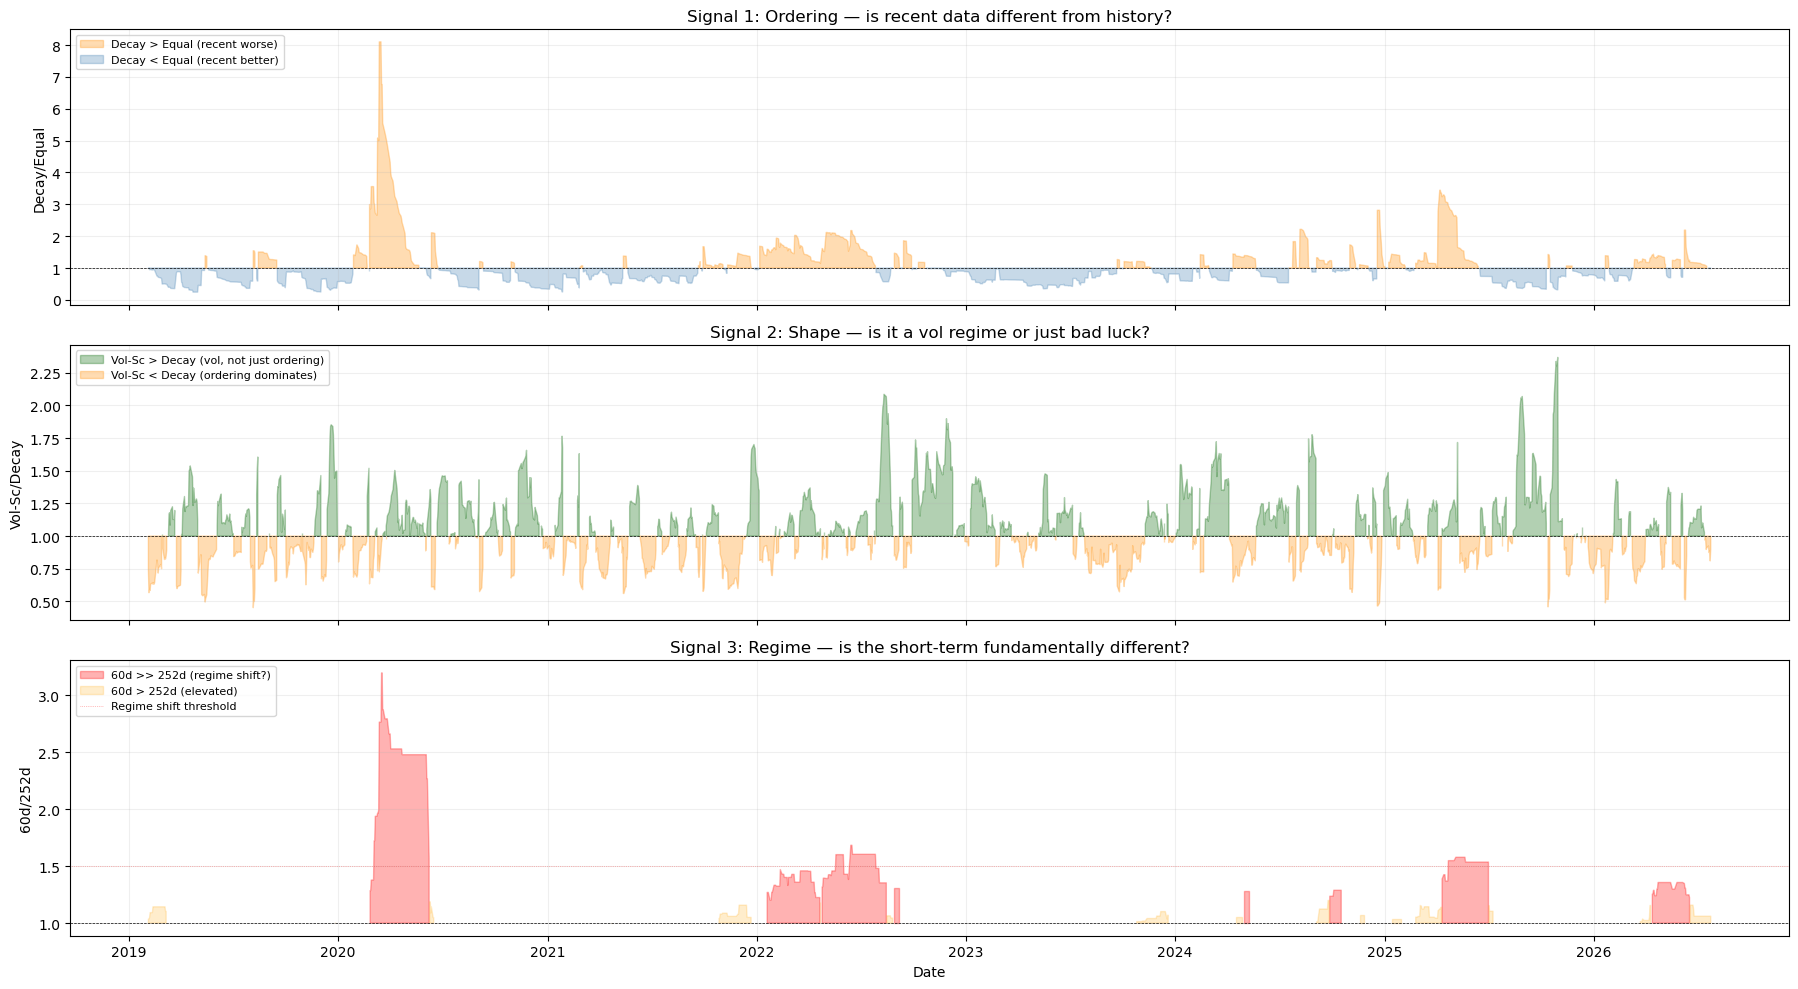

In [7]:
# Three signals from method divergence
common_idx = equal.index.intersection(decay.index).intersection(volscaled.index)

# Signal 1: Decay vs Equal — is recent data worse than history?
ordering_signal = decay.loc[common_idx, "VaR"] / equal.loc[common_idx, "VaR"]

# Signal 2: Vol-scaled vs Decay — is it just vol or is shape changing?
shape_signal = volscaled.loc[common_idx, "VaR"] / decay.loc[common_idx, "VaR"]

# Signal 3: 60d vs 252d — regime shift detection
common_60 = common_idx.intersection(fast60.index)
regime_signal = fast60.loc[common_60, "VaR"] / equal.loc[common_60, "VaR"]

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

# Top: Ordering
axes[0].fill_between(ordering_signal.index, 1.0, ordering_signal.values,
                     where=(ordering_signal.values > 1.0), alpha=0.3, color="darkorange",
                     label="Decay > Equal (recent worse)")
axes[0].fill_between(ordering_signal.index, ordering_signal.values, 1.0,
                     where=(ordering_signal.values < 1.0), alpha=0.3, color="steelblue",
                     label="Decay < Equal (recent better)")
axes[0].axhline(1.0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_ylabel("Decay/Equal")
axes[0].set_title("Signal 1: Ordering — is recent data different from history?")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(True, alpha=0.2)

# Middle: Shape
axes[1].fill_between(shape_signal.index, 1.0, shape_signal.values,
                     where=(shape_signal.values > 1.0), alpha=0.3, color="darkgreen",
                     label="Vol-Sc > Decay (vol, not just ordering)")
axes[1].fill_between(shape_signal.index, shape_signal.values, 1.0,
                     where=(shape_signal.values < 1.0), alpha=0.3, color="darkorange",
                     label="Vol-Sc < Decay (ordering dominates)")
axes[1].axhline(1.0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("Vol-Sc/Decay")
axes[1].set_title("Signal 2: Shape — is it a vol regime or just bad luck?")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(True, alpha=0.2)

# Bottom: Regime
axes[2].fill_between(regime_signal.index, 1.0, regime_signal.values,
                     where=(regime_signal.values > 1.2), alpha=0.3, color="red",
                     label="60d >> 252d (regime shift?)")
axes[2].fill_between(regime_signal.index, 1.0, regime_signal.values,
                     where=((regime_signal.values > 1.0) & (regime_signal.values <= 1.2)),
                     alpha=0.2, color="orange", label="60d > 252d (elevated)")
axes[2].axhline(1.0, color="black", linewidth=0.5, linestyle="--")
axes[2].axhline(1.5, color="red", linewidth=0.5, linestyle=":", alpha=0.5,
               label="Regime shift threshold")
axes[2].set_ylabel("60d/252d")
axes[2].set_xlabel("Date")
axes[2].set_title("Signal 3: Regime — is the short-term fundamentally different?")
axes[2].legend(loc="upper left", fontsize=8)
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Interpreting the three signals together

| Signal 1 (Ordering) | Signal 2 (Shape) | Signal 3 (Regime) | Interpretation | Action |
|---------------------|-----------------|-------------------|----------------|--------|
| ~1.0 | ~1.0 | ~1.0 | All methods agree. Risk is stable. | Standard monitoring. |
| >1.0 | ~1.0 | <1.5 | Recent data is worse, but it's just bad luck, not a regime shift. | Review, don't act yet. |
| >1.0 | >1.0 | <1.5 | Recent data is worse AND vol is rising. Escalating. | Prepare to tighten. |
| >1.0 | >1.0 | >1.5 | ALL signals firing. Regime shift + vol spike + recent worse. | Tighten limits now. |
| <1.0 | <1.0 | <1.0 | Recent better than history. Vol calming. | Consider relaxing. |

**Portfolio context:** When all three signals fire simultaneously on a portfolio, the question becomes: *is this a broad market move or a correlation breakdown?* That's where the portfolio-specific signals in Part D come in.

---

## Part C: Three crises through the portfolio dashboard

Let's walk through three market environments with all methods visible — now with the portfolio perspective.

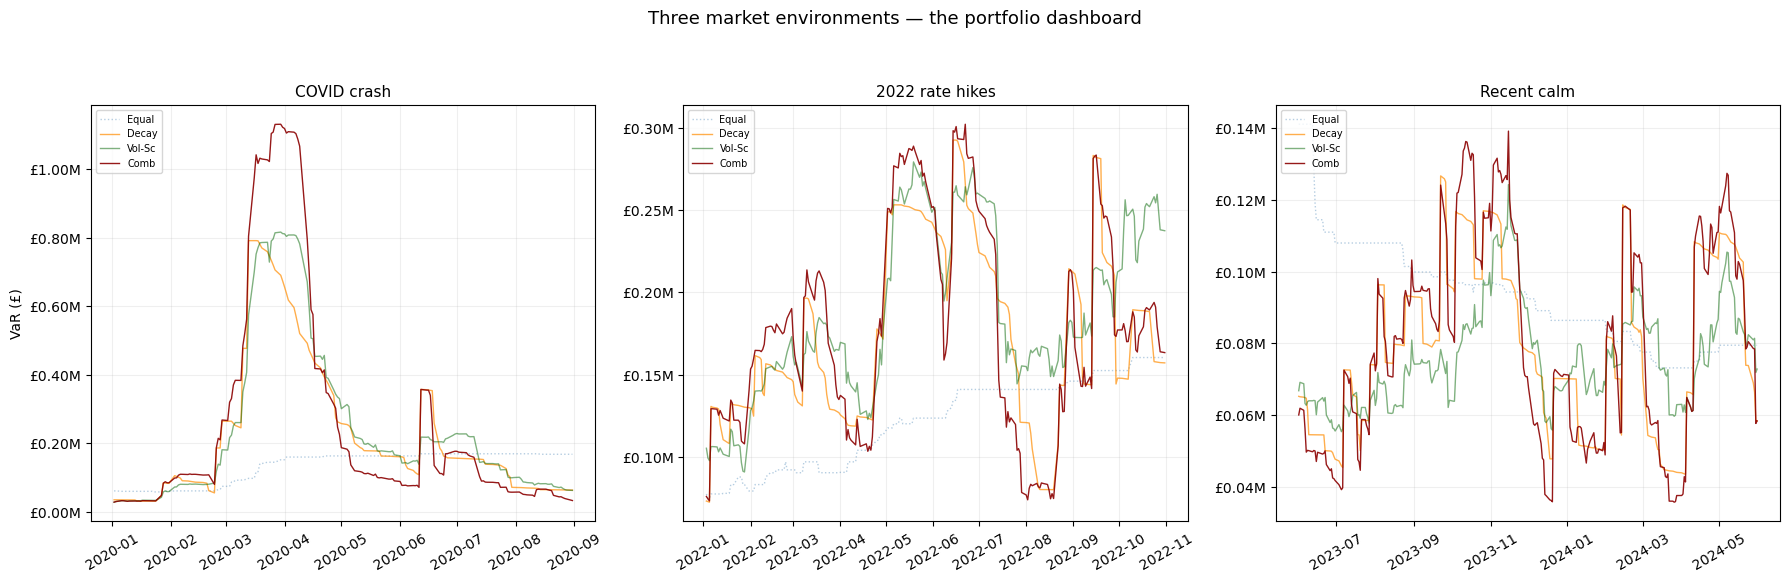

In [8]:
episodes = [
    ("COVID crash", "2020-01-02", "2020-08-31"),
    ("2022 rate hikes", "2022-01-03", "2022-10-31"),
    ("Recent calm", "2023-06-01", "2024-06-01"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (title, start, end) in zip(axes, episodes):
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    panel_methods = [
        (equal, "Equal", "steelblue", 0.4, ":"),
        (decay, "Decay", "darkorange", 0.7, "-"),
        (volscaled, "Vol-Sc", "darkgreen", 0.5, "-"),
        (combined, "Comb", "darkred", 0.9, "-"),
    ]
    for res, label, color, alpha, ls in panel_methods:
        mask = (res.index >= s) & (res.index <= e)
        ax.plot(res.index[mask], res["VaR"][mask] * PORTFOLIO_VALUE,
                linewidth=1.0, color=color, alpha=alpha, linestyle=ls, label=label)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1e6:.2f}M'))
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel("VaR (£)")
plt.suptitle("Three market environments — the portfolio dashboard", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

### What you'd see during each episode — portfolio perspective

**COVID (left):** All methods spike, but at different speeds. Fast 60d and decay react within days. Equal takes weeks. The portfolio VaR jumps because both assets are falling — but BND provides some cushion. The divergence between methods tells you \"something big is happening.\"

**2022 rate hikes (middle):** This is where the portfolio perspective matters most. Unlike COVID (a sharp crash), 2022 is a slow grind where *both asset classes fall together*. The equal-weighted VaR drifts up but lags the reality — the 252-day window still contains pre-2022 data where bonds were a hedge. The gap between decay and equal is the staleness in your diversification assumption.

**Recent calm (right):** All methods converge. Risk is low. The dashboard is boring — and that's good. But the question to ask is: *is the current correlation environment different from what the 252-day window remembers?*

---

## Part D: The portfolio-specific signals

The method-divergence signals (Part B) tell you *that* something is changing. The portfolio-specific signals tell you *what* is changing and *what to do about it*.

Four panels, three signals:

1. **Diversification benefit** — reliability gauge. Is your VaR number trustworthy?
2. **Correlation ratio (60d/252d)** — staleness detector. Has correlation shifted from the long-term average?
3. **Asymmetric adjusted VaR** — the refined estimate. Only activates when correlation is rising (VaR understated), not when it's falling (VaR already conservative). From Notebook 15b: this beats baseline on breach calibration.
4. **Breach comparison** — did the adjustment help?

In [9]:
# Signal 1: Rolling diversification benefit
rv_spy = rolling_var(aligned[TICKERS[0]], window=VAR_WINDOW, confidence=CONFIDENCE)
rv_bnd = rolling_var(aligned[TICKERS[1]], window=VAR_WINDOW, confidence=CONFIDENCE)
rv_portfolio = rolling_var(portfolio_returns, window=VAR_WINDOW, confidence=CONFIDENCE)

# Naive sum: weighted blend of individual VaRs (ρ = +1 worst case)
naive_sum = WEIGHTS[0] * rv_spy["VaR"] + WEIGHTS[1] * rv_bnd["VaR"]

# Diversification benefit
benefit = (naive_sum - rv_portfolio["VaR"]) / naive_sum

print(f"Diversification benefit over time:")
print(f"  Mean:   {benefit.mean():.1%}")
print(f"  Min:    {benefit.min():.1%}  (date: {benefit.idxmin().date()})")
print(f"  Max:    {benefit.max():.1%}  (date: {benefit.idxmax().date()})")
print(f"  Latest: {benefit.iloc[-1]:.1%}  (date: {benefit.index[-1].date()})")

Diversification benefit over time:
  Mean:   16.3%
  Min:    3.8%  (date: 2021-06-14)
  Max:    31.6%  (date: 2024-11-13)
  Latest: 14.9%  (date: 2026-07-24)


In [10]:
# Signal 2: Correlation ratio (60d / 252d)
corr_252 = aligned[TICKERS[0]].rolling(CORR_WINDOW_SLOW).corr(aligned[TICKERS[1]])
corr_60 = aligned[TICKERS[0]].rolling(CORR_WINDOW_FAST).corr(aligned[TICKERS[1]])
corr_252 = corr_252.dropna()
corr_60 = corr_60.dropna()
common_corr = corr_252.index.intersection(corr_60.index)
corr_ratio = (corr_60.loc[common_corr] / corr_252.loc[common_corr]).replace([np.inf, -np.inf], np.nan)

print(f"Correlation ratio (60d/252d):")
print(f"  Latest:     {corr_ratio.dropna().iloc[-1]:.2f}")
print(f"  Mean:       {corr_ratio.dropna().mean():.2f}")
print(f"  Days |ratio − 1| > 0.5: {(corr_ratio.dropna().abs().sub(1).abs() > 0.5).sum()}")

Correlation ratio (60d/252d):
  Latest:     1.83
  Mean:       1.12
  Days |ratio − 1| > 0.5: 1163


In [11]:
# Signal 3: Asymmetric correlation-adjusted VaR (refined from Notebook 15b)
# Only adjusts when correlation is rising (ratio > threshold) — VaR understated.
# When correlation is falling, stays at α = 1 — baseline VaR is already conservative.

def asymmetric_alpha(ratio, threshold=1.2, blend_max=3.0):
    """Asymmetric blend: only activates when ratio > threshold (correlation rising).
    
    When ratio ≤ threshold: α = 1 (fully trust baseline).
    When ratio > threshold: α ramps from 1 to 0 linearly.
    """
    alpha = np.ones_like(ratio, dtype=float)
    mask = ratio > threshold
    if mask.any():
        deviation = ratio[mask] - threshold
        max_dev = blend_max - threshold
        alpha[mask] = 1.0 - np.clip(deviation / max_dev, 0, 1)
    return alpha

# Align all series to common dates
dates = (rv_portfolio.index
         .intersection(naive_sum.index)
         .intersection(corr_ratio.dropna().index))

baseline_var = rv_portfolio.loc[dates, "VaR"]
naive = naive_sum.loc[dates]
ratio_aligned = corr_ratio.loc[dates]
actual_returns = portfolio_returns.loc[dates]

# Compute asymmetric adjusted VaR
alpha = asymmetric_alpha(ratio_aligned.values, ASYM_THRESHOLD, ASYM_BLEND_MAX)
alpha = pd.Series(alpha, index=ratio_aligned.index)
adjusted_var = alpha * baseline_var + (1 - alpha) * naive

# Breach detection
baseline_breach = -actual_returns > baseline_var
adjusted_breach = -actual_returns > adjusted_var

n = len(dates)
expected_rate = 1 - CONFIDENCE
print(f"Aligned observations: {n}")
print(f"\nBaseline VaR:")
print(f"  Mean VaR:     {baseline_var.mean():.3%}")
print(f"  Breaches:     {baseline_breach.sum()} ({baseline_breach.sum()/n:.2%})")
print(f"  Expected:     {expected_rate:.2%}")
print(f"\nAsymmetric Adjusted VaR:")
print(f"  Mean VaR:     {adjusted_var.mean():.3%}")
print(f"  Mean α:       {alpha.mean():.3f}")
print(f"  Days adjusted (α < 1): {(alpha < 1).sum()} ({(alpha < 1).sum()/n:.1%})")
print(f"  Breaches:     {adjusted_breach.sum()} ({adjusted_breach.sum()/n:.2%})")

baseline_dev = abs(baseline_breach.sum()/n - expected_rate)
adj_dev = abs(adjusted_breach.sum()/n - expected_rate)
winner = "Baseline" if baseline_dev < adj_dev else "Adjusted"
ratio_label = "rising" if corr_ratio.dropna().iloc[-1] > 1.0 else "falling"
print(f"\n→ {winner} VaR is closer to expected breach rate "
      f"({baseline_dev:.2%} vs {adj_dev:.2%})")
print(f"  Correlation is currently {ratio_label} (ratio = {corr_ratio.dropna().iloc[-1]:.2f})")

Aligned observations: 1898

Baseline VaR:
  Mean VaR:     1.116%
  Breaches:     98 (5.16%)
  Expected:     5.00%

Asymmetric Adjusted VaR:
  Mean VaR:     1.155%
  Mean α:       0.793
  Days adjusted (α < 1): 903 (47.6%)
  Breaches:     94 (4.95%)

→ Adjusted VaR is closer to expected breach rate (0.16% vs 0.05%)
  Correlation is currently rising (ratio = 1.83)


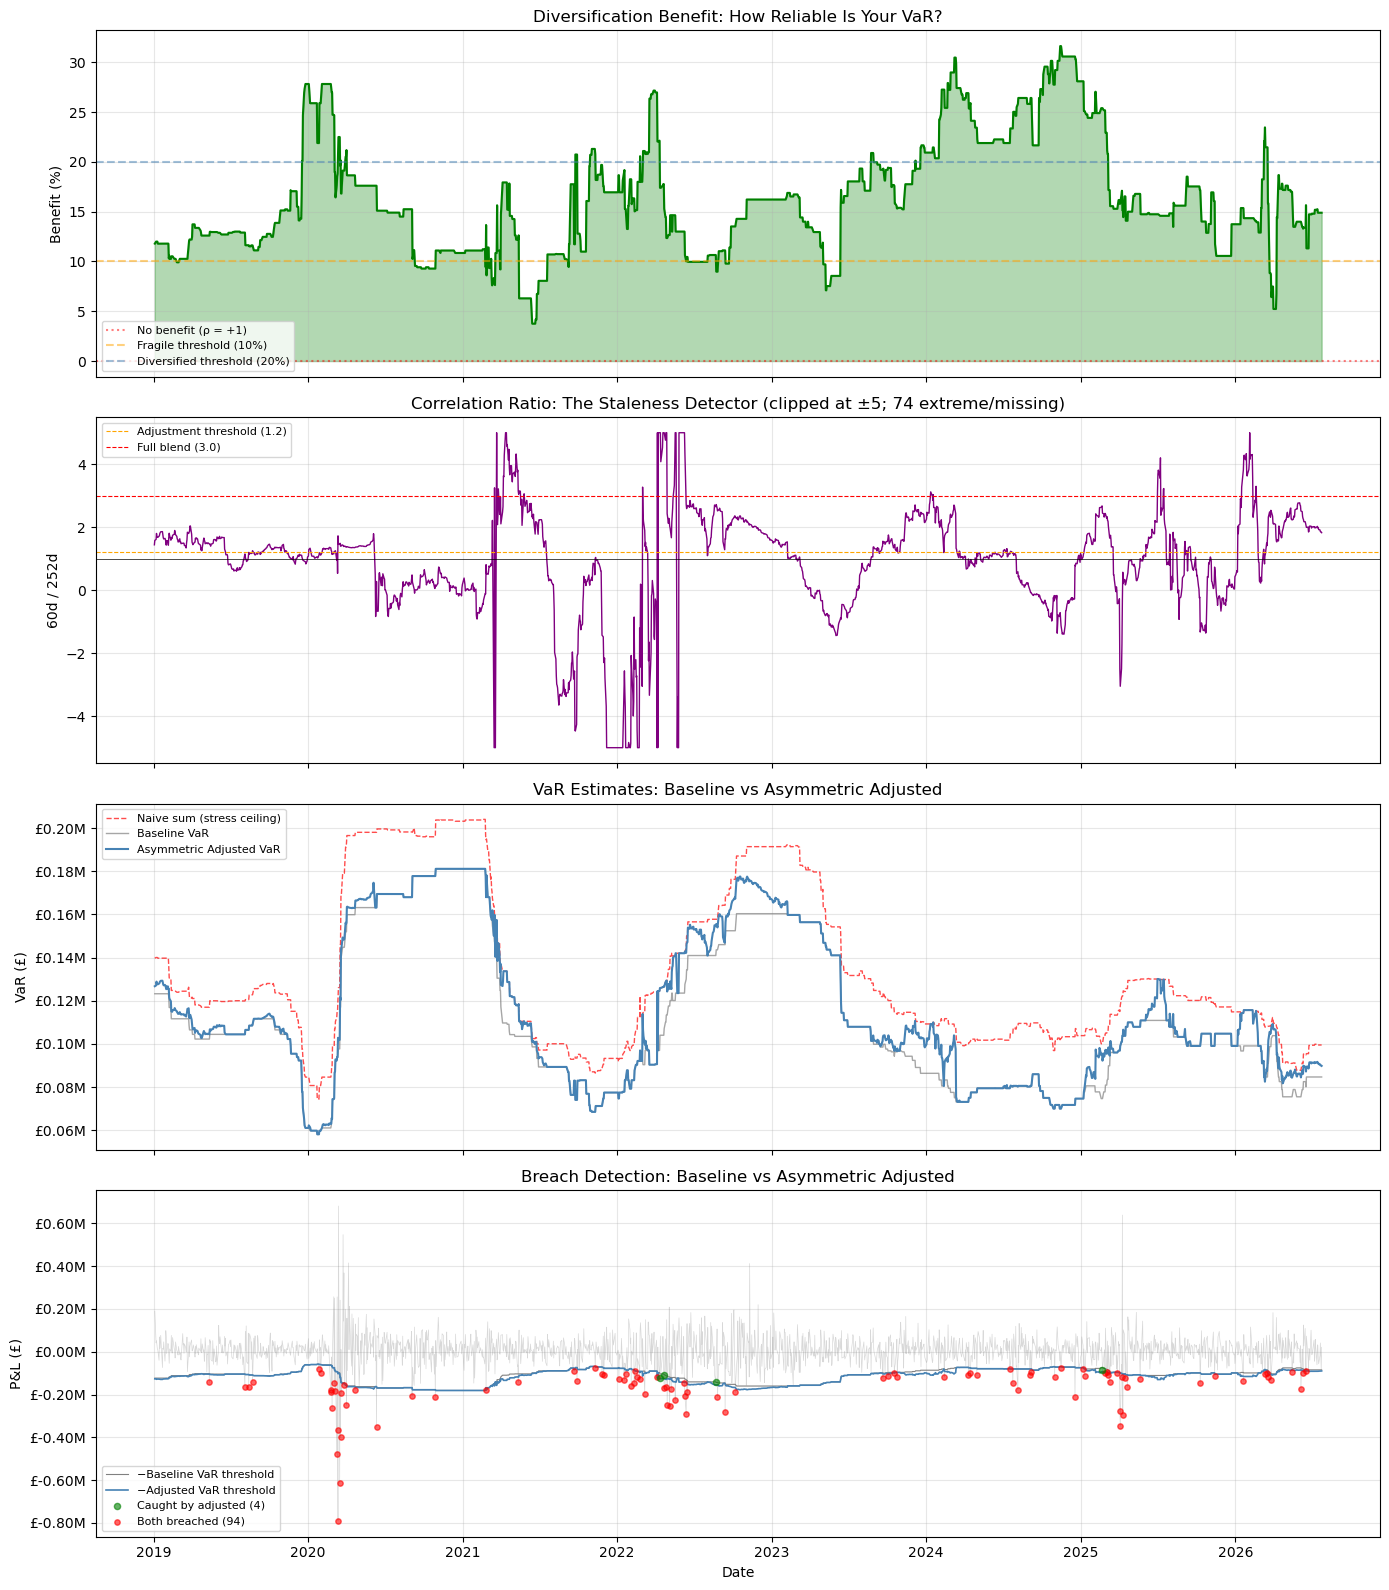

In [12]:
# Portfolio signals dashboard
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Panel 1: Diversification benefit — the reliability gauge
ax = axes[0]
ax.fill_between(benefit.index, 0, benefit * 100, alpha=0.3, color="green")
ax.plot(benefit.index, benefit * 100, color="green", linewidth=1.5)
ax.axhline(y=0, color="red", linestyle=":", alpha=0.5, label="No benefit (ρ = +1)")
ax.axhline(y=10, color="orange", linestyle="--", alpha=0.5, label="Fragile threshold (10%)")
ax.axhline(y=20, color="steelblue", linestyle="--", alpha=0.5, label="Diversified threshold (20%)")
ax.set_ylabel("Benefit (%)")
ax.set_title("Diversification Benefit: How Reliable Is Your VaR?")
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 2: Correlation ratio — the staleness detector
ax = axes[1]
ratio_plot = corr_ratio.clip(lower=-5, upper=5)
ax.plot(ratio_plot.index, ratio_plot, color="purple", linewidth=1)
ax.axhline(y=1.0, color="black", linestyle="-", linewidth=0.5)
ax.axhline(y=ASYM_THRESHOLD, color="orange", linestyle="--", linewidth=0.8,
          label=f"Adjustment threshold ({ASYM_THRESHOLD})")
ax.axhline(y=ASYM_BLEND_MAX, color="red", linestyle="--", linewidth=0.8,
          label=f"Full blend ({ASYM_BLEND_MAX})")
n_extreme = ((corr_ratio.abs() > 5) | corr_ratio.isna()).sum()
ax.set_ylabel("60d / 252d")
ax.set_title(f"Correlation Ratio: The Staleness Detector (clipped at ±5; {n_extreme} extreme/missing)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: VaR comparison — baseline vs asymmetric adjusted
ax = axes[2]
ax.plot(naive.index, naive * PORTFOLIO_VALUE, label="Naive sum (stress ceiling)",
        color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.plot(baseline_var.index, baseline_var * PORTFOLIO_VALUE, label="Baseline VaR",
        color="gray", linewidth=1, alpha=0.7)
ax.plot(adjusted_var.index, adjusted_var * PORTFOLIO_VALUE, label="Asymmetric Adjusted VaR",
        color="steelblue", linewidth=1.5)
ax.set_ylabel("VaR (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1e6:.2f}M'))
ax.set_title("VaR Estimates: Baseline vs Asymmetric Adjusted")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: Breach comparison
ax = axes[3]
ax.plot(actual_returns.index, actual_returns * PORTFOLIO_VALUE,
        color="gray", alpha=0.3, linewidth=0.5)
ax.plot(baseline_var.index, -baseline_var * PORTFOLIO_VALUE,
        color="gray", linewidth=0.8, label="−Baseline VaR threshold")
ax.plot(adjusted_var.index, -adjusted_var * PORTFOLIO_VALUE,
        color="steelblue", linewidth=1.2, label="−Adjusted VaR threshold")
# Highlight where adjusted prevented a breach that baseline missed
caught = baseline_breach & ~adjusted_breach
if caught.any():
    ax.scatter(caught.index[caught], actual_returns.loc[caught.index[caught]] * PORTFOLIO_VALUE,
              color="green", s=20, alpha=0.6, zorder=5,
              label=f"Caught by adjusted ({caught.sum()})")
still_breach = baseline_breach & adjusted_breach
if still_breach.any():
    ax.scatter(still_breach.index[still_breach],
              actual_returns.loc[still_breach.index[still_breach]] * PORTFOLIO_VALUE,
              color="red", s=15, alpha=0.6, zorder=4,
              label=f"Both breached ({still_breach.sum()})")
ax.set_ylabel("P&L (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1e6:.2f}M'))
ax.set_xlabel("Date")
ax.set_title("Breach Detection: Baseline vs Asymmetric Adjusted")
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Reading the portfolio signals together

The four panels are designed to be read together — each answers a different question:

| Panel | Question | Quick read |
|-------|----------|------------|
| **Benefit** (top) | Is my VaR reliable? | Green high → trust it. Green low → stress ahead. |
| **Correlation ratio** | Has correlation shifted? | Near 1 → stable. Far above 1 → VaR is understated. Below 1 → VaR is conservative (no action needed). |
| **VaR comparison** | What number should I use? | Blue line lifts toward red only when correlation is rising → asymmetric in action. |
| **Breach detection** (bottom) | Did the adjustment help? | Green dots = breaches caught. Red dots = even the adjusted couldn't catch. |

**The key interaction:** When the benefit drops (panel 1) AND the correlation ratio spikes above 1.2 (panel 2), the asymmetric adjusted VaR (panel 3) moves toward the naive sum — but only then. When correlation is falling, the blue line hugs the gray baseline. This is the asymmetry at work: adjusting when it matters, staying put when it doesn't.

**The Notebook 15b finding:** This asymmetric approach, with the right threshold calibration, actually *beats* baseline on breach rate deviation. The adjustment earns its keep — it's not just theoretical.

---

## Part E: The complete picture

All six signals on one page — the VaR dashboard methods plus the portfolio-specific signals. This is what you'd check at 8am before the daily risk meeting.

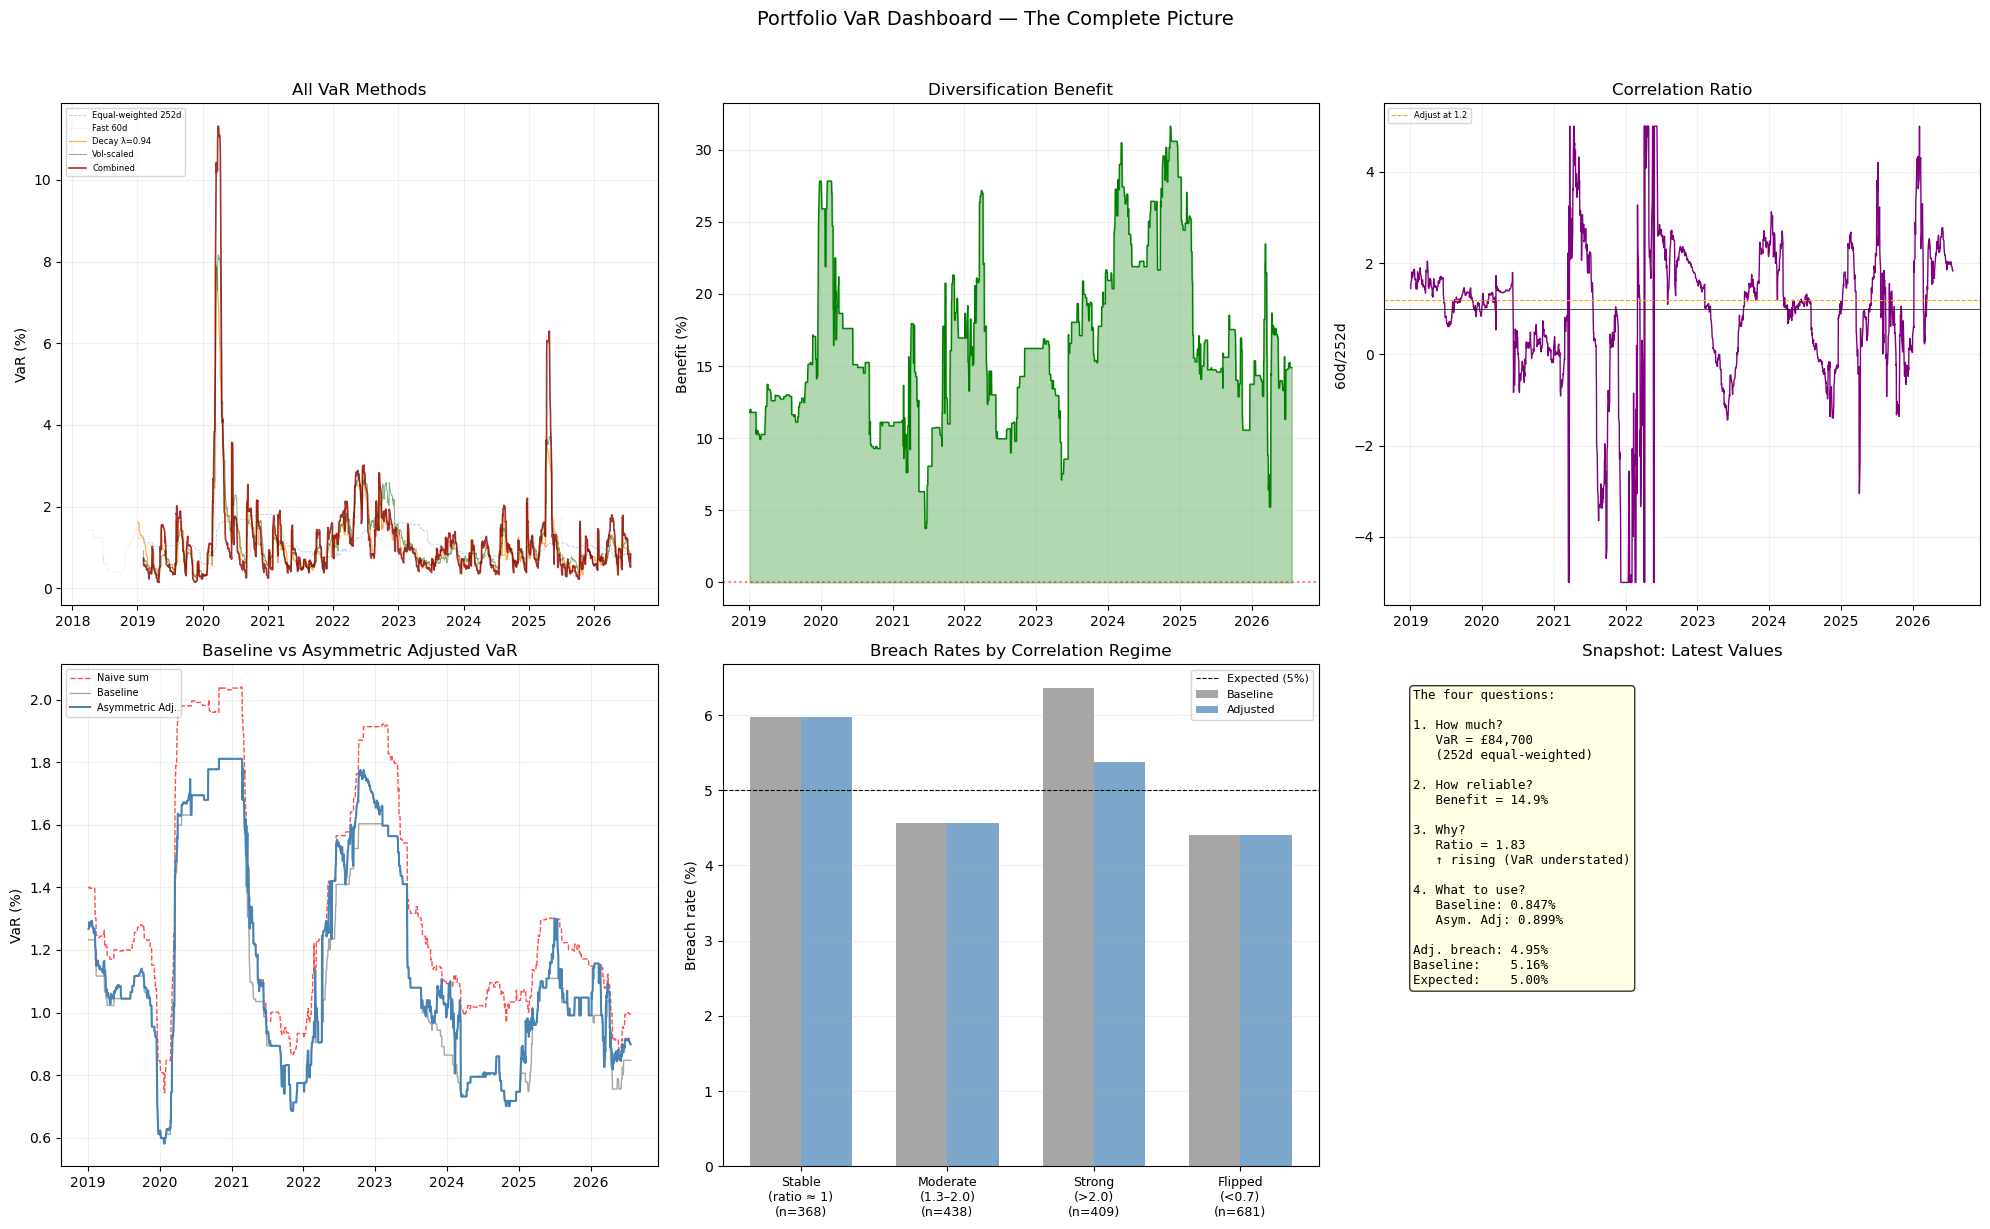

In [13]:
# The complete picture — 2x3 grid combining all signals
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Row 1, Col 1: VaR methods dashboard (compact)
ax = axes[0, 0]
for res, label, color, alpha, ls, lw in methods:
    ax.plot(res.index, res["VaR"] * 100, linewidth=lw, color=color,
            alpha=alpha, linestyle=ls, label=label)
ax.set_ylabel("VaR (%)")
ax.set_title("All VaR Methods")
ax.legend(fontsize=6, loc="upper left")
ax.grid(True, alpha=0.2)

# Row 1, Col 2: Diversification benefit
ax = axes[0, 1]
ax.fill_between(benefit.index, 0, benefit * 100, alpha=0.3, color="green")
ax.plot(benefit.index, benefit * 100, color="green", linewidth=1)
ax.axhline(y=0, color="red", linestyle=":", alpha=0.5)
ax.set_ylabel("Benefit (%)")
ax.set_title("Diversification Benefit")
ax.grid(True, alpha=0.2)

# Row 1, Col 3: Correlation ratio
ax = axes[0, 2]
ax.plot(ratio_plot.index, ratio_plot, color="purple", linewidth=1)
ax.axhline(y=1.0, color="black", linestyle="-", linewidth=0.5)
ax.axhline(y=ASYM_THRESHOLD, color="orange", linestyle="--", linewidth=0.8,
          label=f"Adjust at {ASYM_THRESHOLD}")
ax.set_ylabel("60d/252d")
ax.set_title("Correlation Ratio")
ax.legend(fontsize=6, loc="upper left")
ax.grid(True, alpha=0.2)

# Row 2, Col 1: Baseline vs Asymmetric Adjusted VaR
ax = axes[1, 0]
ax.plot(naive.index, naive * 100, label="Naive sum", color="red",
        linestyle="--", linewidth=1, alpha=0.7)
ax.plot(baseline_var.index, baseline_var * 100, label="Baseline",
        color="gray", linewidth=1, alpha=0.7)
ax.plot(adjusted_var.index, adjusted_var * 100, label="Asymmetric Adj.",
        color="steelblue", linewidth=1.5)
ax.set_ylabel("VaR (%)")
ax.set_title("Baseline vs Asymmetric Adjusted VaR")
ax.legend(fontsize=7, loc="upper left")
ax.grid(True, alpha=0.2)

# Row 2, Col 2: Breach rates by correlation regime
ax = axes[1, 1]
regimes = {
    "Stable\n(ratio ≈ 1)": (0.7, 1.3),
    "Moderate\n(1.3–2.0)": (1.3, 2.0),
    "Strong\n(>2.0)": (2.0, 99),
    "Flipped\n(<0.7)": (-99, 0.7),
}
labels, base_rates, adj_rates = [], [], []
for label, (lo, hi) in regimes.items():
    mask = (ratio_aligned >= lo) & (ratio_aligned < hi)
    if mask.sum() == 0:
        continue
    nd = mask.sum()
    labels.append(f"{label}\n(n={nd})")
    base_rates.append(baseline_breach[mask].sum() / nd * 100)
    adj_rates.append(adjusted_breach[mask].sum() / nd * 100)

x = np.arange(len(labels))
width = 0.35
bars1 = ax.bar(x - width/2, base_rates, width, label="Baseline", color="gray", alpha=0.7)
bars2 = ax.bar(x + width/2, adj_rates, width, label="Adjusted", color="steelblue", alpha=0.7)
ax.axhline(y=expected_rate*100, color="black", linestyle="--", linewidth=0.8,
          label=f"Expected ({expected_rate*100:.0f}%)")
ax.set_ylabel("Breach rate (%)")
ax.set_title("Breach Rates by Correlation Regime")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='y')

# Row 2, Col 3: The four questions
ax = axes[1, 2]
ax.axis("off")
ratio_latest = corr_ratio.dropna().iloc[-1]
direction = "↑ rising (VaR understated)" if ratio_latest > 1.0 else "↓ falling (VaR conservative)"
summary_lines = [
    "The four questions:",
    "",
    f"1. How much?",
    f"   VaR = £{equal.iloc[-1]['VaR']*PORTFOLIO_VALUE:,.0f}",
    f"   (252d equal-weighted)",
    "",
    f"2. How reliable?",
    f"   Benefit = {benefit.iloc[-1]:.1%}",
    "",
    f"3. Why?",
    f"   Ratio = {ratio_latest:.2f}",
    f"   {direction}",
    "",
    f"4. What to use?",
    f"   Baseline: {baseline_var.iloc[-1]:.3%}",
    f"   Asym. Adj: {adjusted_var.iloc[-1]:.3%}",
    "",
    f"Adj. breach: {adjusted_breach.sum()/n:.2%}",
    f"Baseline:    {baseline_breach.sum()/n:.2%}",
    f"Expected:    {expected_rate:.2%}",
]
summary_text = "\n".join(summary_lines)
ax.text(0.05, 0.95, summary_text, transform=ax.transAxes,
        fontsize=9, fontfamily="monospace", verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
ax.set_title("Snapshot: Latest Values")

plt.suptitle("Portfolio VaR Dashboard — The Complete Picture", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### The escalation ladder — portfolio edition

Combining all signals into an action framework:

| Level | VaR methods | Benefit | Corr ratio | Adj. VaR | Action |
|-------|------------|---------|------------|----------|--------|
| **Green** | All agree, low | >20% | ~1.0 | ≈ Baseline | Standard monitoring. Weekly review. |
| **Yellow** | One method elevated | 10-20% | 1.0-1.2 | Slight lift | Note elevated risk. Watch tomorrow. |
| **Orange** | Two methods elevated | 5-10% | 1.2-2.0 | Visible gap | Review positions. Check correlation regime. Use adjusted VaR. |
| **Red** | All firing | <5% | >2.0 | Wide gap | Tighten limits immediately. Adjusted VaR is your working number. Escalate. |

**The key design principle from Notebook 15b:** The asymmetric adjusted VaR only activates when correlation is *rising* (VaR understated). When correlation is falling, it stays at baseline — no unnecessary conservatism. This means the adjusted number has credibility: when it differs from baseline, there's a real reason.

**The escalation logic builds on the single-asset framework (Notebook 11) but adds the portfolio dimension:** when all single-asset signals fire AND the benefit is collapsing, you're not just looking at higher vol — you're looking at a correlation breakdown that invalidates your diversification assumptions. The asymmetric adjusted VaR gives you a better-calibrated number to use while you figure out what to do.

---

## Part F: Practical interpretation — putting it all to work

### Spreadex context — the live trading desk

You're monitoring a multi-asset book. The dashboard is open on your second screen. At 8am, you scan the six panels:

1. **VaR methods (top-left):** Are the lines clustered or diverging? Clustered = stable. Diverging = investigate.
2. **Benefit (top-centre):** Is the green area shrinking? Shrinking = diversification failing. This is your earliest warning.
3. **Correlation ratio (top-right):** Above 1.2? The asymmetric adjustment activates — correlation is rising, VaR is understated.
4. **Baseline vs adjusted (bottom-left):** How wide is the gap? Wide gap = standard VaR is stale. The blue line only separates from gray when correlation is rising — that's the asymmetry at work.
5. **Breach rates by regime (bottom-centre):** In the current regime, which VaR number is better calibrated? The bar chart tells you whether baseline or adjusted has been more accurate.
6. **Snapshot (bottom-right):** The four numbers you quote in the morning meeting — including the correlation direction, which tells you *why* adjusted VaR differs from baseline.

**You don't need all six to be green to sleep at night.** You need to know which ones are red and what you're doing about it.

### FINBOURNE context — institutional reporting

For an institutional client receiving a daily VaR report:

- The **baseline VaR** is the headline number — it's what they're used to seeing.
- The **diversification benefit** tells them how much of their portfolio risk is being offset by holding multiple assets. A shrinking benefit is a conversation starter.
- The **asymmetric adjusted VaR** is a supplementary number — \"standard VaR is X, but correlation is currently rising — our adjusted estimate is Y, which has been better calibrated to actual breach rates.\" It demonstrates that you're thinking beyond the blind application of a formula. And because it only activates when there's a real reason (correlation rising), it has more credibility than a symmetric adjustment that's always pulling in both directions.

### Personal toolkit development

This notebook is a template. Change TICKERS and WEIGHTS to monitor any 2-asset portfolio:
- SPY/GLD (equity/gold hedge)
- SPY/TLT (equity/long-duration bonds)
- QQQ/IWM (growth/value rotation)

The three portfolio-specific signals (benefit, ratio, asymmetric adjusted VaR) work for any pair. The method-divergence signals are universal. **Re-run the threshold sweep (Notebook 15b) for each new pair** — the optimal parameters are asset-specific.

### Limitations — what this dashboard doesn't tell you

| Limitation | Why it matters | What to do |
|-----------|---------------|------------|
| **2-asset only** | Real portfolios have 10-100+ positions | Generalise to n-asset in Notebook 16 |
| **Ratio is contemporaneous** | From Notebook 13b: correlation doesn't lead VaR | The adjustment is a now-cast, not a forecast. It corrects staleness in real time. |
| **Parameters are asset-specific** | Optimal threshold varies by pair | Re-run the sweep from Notebook 15b for each new portfolio |
| **Still backward-looking** | The adjusted VaR corrects staleness but doesn't predict | Use alongside forward-looking stress scenarios |
| **Fixed weights** | Real weights drift with market moves | Rebalance monitoring is a separate concern |
| **Historical only** | No parametric or Monte Carlo comparison | Those come in later phases |
| **Single horizon** | 1-day VaR misses multi-day cumulative risk | Multi-horizon portfolio VaR is future work |

---

## Key takeaways

1. **All five VaR methods work on portfolio returns without modification.** Compute the weighted portfolio return series, then run the same `rolling_var`, `rolling_decay_var`, and vol-scaled/combined loops. The architecture was designed for this.
2. **Three portfolio-specific signals extend the dashboard beyond the single-asset version.** The diversification benefit tells you *how reliable* your VaR is. The correlation ratio tells you *why* it's changing. The asymmetric adjusted VaR tells you *what number to use* when correlation is rising — and only then.
3. **The asymmetric adjusted VaR beats baseline when calibrated.** From Notebook 15b: with threshold=1.2 and blend_max=3.0, breach rate deviation drops to +0.05% (vs baseline's +0.16%). The key insight: only adjust when correlation is rising (VaR understated), not when it's falling (VaR already conservative).
4. **The dashboard distinguishes correlation-driven risk from vol-driven risk.** When all methods rise but the benefit stays high, it's a vol event — diversification is still working. When the benefit collapses AND the ratio spikes, it's a correlation event — your hedge is failing. The asymmetric adjusted VaR activates precisely in this second scenario.
5. **The escalation ladder adds the portfolio dimension.** Red signals on the single-asset methods PLUS a collapsing benefit PLUS ratio > 1.2 = correlation breakdown. The asymmetric adjusted VaR is your working number while you decide what to do.
6. **The ratio is a staleness diagnostic, not a leading indicator (Notebook 13b).** The adjustment is a *now-cast* — it corrects staleness in real time, it doesn't predict future breaches. This means the blend needs to be fast enough to catch the regime shift while it's happening.
7. **This is a template, not a fixed report.** Swap TICKERS and WEIGHTS to monitor any 2-asset pair. Re-run the threshold sweep (Notebook 15b) for each new pair. Next: Notebook 16 generalises to n assets.